In [1]:
%matplotlib inline

In [2]:
import cv2
import torch, detectron2
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, Dataset
import json


print("detectron2:", detectron2.__version__)
# Some basic setup:
# Setup detectron2 logger
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import numpy as np
import os, json, cv2, random

from PIL import Image, ImageDraw

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog

detectron2: 0.6


In [3]:
import os
import pandas as pdß
import numpy as np
import pprint
import json
import cv2
import random

import pickle # Load refs and annotations
from typing import Any, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch.utils.tensorboard import SummaryWriter

import torchvision
import torchmetrics


import pytorch_lightning as pl
from pytorch_lightning.utilities.types import STEP_OUTPUT

from transformers import T5Tokenizer, T5ForConditionalGeneration
from transformers import CLIPProcessor, CLIPModel

from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import clip
from ultralytics import YOLO
from PIL import Image, ImageDraw


In [4]:
import os

from detectron2.engine import DefaultTrainer
from detectron2.structures import BoxMode
from detectron2 import model_zoo



import cv2

In [5]:
with open("./refcocog/annotations/instances.json", "rb") as fp:
    data = json.load(fp)

In [6]:
categories_names_coco = []
categories_names_detectron = []
categories_names = []
w = 0
# add a empty category in order to hava the same indexes for detectron2
for i in data['categories']:
    # complete_string = i['id']+ '' +i['name']
    #print(complete_string)
    #categories_names.append(i['name'])
    categories_names.append(i['name'])
    
    categories_names_coco.append({'category':i['name'], 'id':(i['id'])})
    categories_names_detectron.append({'category':i['name'], 'id':w})

    w+=1

In [7]:
categories_names_coco

[{'category': 'person', 'id': 1},
 {'category': 'bicycle', 'id': 2},
 {'category': 'car', 'id': 3},
 {'category': 'motorcycle', 'id': 4},
 {'category': 'airplane', 'id': 5},
 {'category': 'bus', 'id': 6},
 {'category': 'train', 'id': 7},
 {'category': 'truck', 'id': 8},
 {'category': 'boat', 'id': 9},
 {'category': 'traffic light', 'id': 10},
 {'category': 'fire hydrant', 'id': 11},
 {'category': 'stop sign', 'id': 13},
 {'category': 'parking meter', 'id': 14},
 {'category': 'bench', 'id': 15},
 {'category': 'bird', 'id': 16},
 {'category': 'cat', 'id': 17},
 {'category': 'dog', 'id': 18},
 {'category': 'horse', 'id': 19},
 {'category': 'sheep', 'id': 20},
 {'category': 'cow', 'id': 21},
 {'category': 'elephant', 'id': 22},
 {'category': 'bear', 'id': 23},
 {'category': 'zebra', 'id': 24},
 {'category': 'giraffe', 'id': 25},
 {'category': 'backpack', 'id': 27},
 {'category': 'umbrella', 'id': 28},
 {'category': 'handbag', 'id': 31},
 {'category': 'tie', 'id': 32},
 {'category': 'suitca

In [8]:
def mapping_categories(category_id, from_coco_to_det=True):
    
    if from_coco_to_det == True:
        for cat in categories_names_coco:
            if cat['id'] == category_id:
                det_category_name = cat['category']
                break

        for cat in categories_names_detectron:
            if cat['category'] == det_category_name:
                det_category_id = cat['id']
                break
            
        return det_category_id
    
    if from_coco_to_det == False:
        for cat in categories_names_detectron:
            if cat['id'] == category_id:
                det_category_name = cat['category']
                break

        for cat in categories_names_coco:
            if cat['category'] == det_category_name:
                coco_category_id = cat['id']
                break
    
        return coco_category_id

In [60]:
ciao = mapping_categories(39, from_coco_to_det=False)
ciao

44

In [9]:
def rel_to_abs(bbox, width, height):
    """
    Trasforma una bounding box da coordinate relative a coordinate assolute.
    
    Parameters:
    bbox (list or tuple): bounding box in formato [x_min, y_min, x_max, y_max] con coordinate relative.
    width (int): larghezza dell'immagine.
    height (int): altezza dell'immagine.
    
    Returns:
    list: bounding box in formato [x_min, y_min, x_max, y_max] con coordinate assolute.
    """
    x_min_rel, y_min_rel, x_max_rel, y_max_rel = bbox
    x_min_abs = int(x_min_rel * width)
    y_min_abs = int(y_min_rel * height)
    x_max_abs = int(x_max_rel * width)
    y_max_abs = int(y_max_rel * height)
    return [x_min_abs, y_min_abs, x_max_abs, y_max_abs]

In [10]:
def create_coco_train_dict():

    with open("./refcocog/annotations/refs(umd).p", "rb") as fp:
        refs = pickle.load(fp)

    # 'annotations' will be a dict object mapping the 'annotation_id' to the 'bbox' to make search faster
    with open("./refcocog/annotations/instances.json", "rb") as fp:
        data = json.load(fp)
        annotations = dict(sorted({ann["id"]: (ann["bbox"], ann["category_id"], ann["image_id"]) for ann in data["annotations"]}.items()))

    dataset = list()

    for elem in [d for d in refs if d["split"]=="train"]:
        file_name = os.path.join("./refcocog/images/", f'{"_".join(elem["file_name"].split("_")[:3])}.jpg')
        height, width = cv2.imread(file_name).shape[:2]
        sentences = elem['sentences']
        
        raws = []
        for i in sentences:
            raws.append(i['raw'])
        

        bbox, category_id, image_id = annotations[elem['ann_id']]
        bbox = rel_to_abs(bbox, width, height)
        category_id = mapping_categories(category_id, from_coco_to_det=True)
        for i in raws:
            dataset.append({"file_name":file_name, "raw":i, "image_id":image_id, "height":height, "width":width, "annotations": [{"bbox":bbox, "category_id":category_id, "bbox_mode":BoxMode.XYXY_ABS}]})
    return dataset


In [11]:
def create_coco_test_dict():

    with open("./refcocog/annotations/refs(umd).p", "rb") as fp:
        refs = pickle.load(fp)

    # 'annotations' will be a dict object mapping the 'annotation_id' to the 'bbox' to make search faster
    with open("./refcocog/annotations/instances.json", "rb") as fp:
        data = json.load(fp)
        annotations = dict(sorted({ann["id"]: (ann["bbox"], ann["category_id"], ann["image_id"]) for ann in data["annotations"]}.items()))

    dataset = list()

    for elem in [d for d in refs if d["split"]=="test"]:
        file_name = os.path.join("./refcocog/images/", f'{"_".join(elem["file_name"].split("_")[:3])}.jpg')
        height, width = cv2.imread(file_name).shape[:2]
        sentences = elem['sentences']
        
        raws = []
        for i in sentences:
            raws.append(i['raw'])
        

        bbox, category_id, image_id = annotations[elem['ann_id']]
        bbox = rel_to_abs(bbox, width, height)
        category_id = mapping_categories(category_id, from_coco_to_det=True)
        for i in raws:
            dataset.append({"file_name":file_name, "raw":i, "image_id":image_id, "height":height, "width":width, "annotations": [{"bbox":bbox, "category_id":category_id, "bbox_mode":BoxMode.XYXY_ABS}]})
    return dataset

In [12]:
train_dataset = create_coco_train_dict()

In [13]:
test_dataset = create_coco_test_dict()

Registrazione Dataset

In [14]:
DatasetCatalog.register('my_data_train', create_coco_train_dict)
DatasetCatalog.register('my_data_test', create_coco_test_dict)

# Set the metadata for the dataset.
#MetadataCatalog.get('my_data_train').set(thing_classes=categories_names_coco['category'])
#MetadataCatalog.get('my_data_test').set(thing_classes=categories_names_coco['category'])
MetadataCatalog.get('my_data_train').set(thing_classes=categories_names)
MetadataCatalog.get('my_data_test').set(thing_classes=categories_names)

namespace(name='my_data_test',
          thing_classes=['person',
                         'bicycle',
                         'car',
                         'motorcycle',
                         'airplane',
                         'bus',
                         'train',
                         'truck',
                         'boat',
                         'traffic light',
                         'fire hydrant',
                         'stop sign',
                         'parking meter',
                         'bench',
                         'bird',
                         'cat',
                         'dog',
                         'horse',
                         'sheep',
                         'cow',
                         'elephant',
                         'bear',
                         'zebra',
                         'giraffe',
                         'backpack',
                         'umbrella',
                         'handbag',
             

In [15]:
def create_cfg(output_dir, learning_rate, batch_size, iterations, checkpoint_period, model, device, nmr_classes):
    """
    Create a Detectron2 configuration object and set its attributes.

    Args:
        output_dir (str): The path to the output directory where the trained model and logs will be saved.
        learning_rate (float): The learning rate for the optimizer.
        batch_size (int): The batch size used during training.
        iterations (int): The maximum number of training iterations.
        checkpoint_period (int): The number of iterations between consecutive checkpoints.
        model (str): The name of the model to use, which should be one of the models available in Detectron2's model zoo.
        device (str): The device to use for training, which should be 'cpu' or 'cuda'.
        nmr_classes (int): The number of classes in the dataset.

    Returns:
        The Detectron2 configuration object.
    """
    cfg = get_cfg()

    # Merge the model's default configuration file with the default Detectron2 configuration file.
    cfg.merge_from_file(model_zoo.get_config_file(model))

    # Set the training and validation datasets and exclude the test dataset.
    cfg.DATASETS.TRAIN = ("my_data_train",)
    cfg.DATASETS.VAL = ("my_data_train",)
    cfg.DATASETS.TEST = ()

    # Set the device to use for training.
    if device in ['cpu']:
        cfg.MODEL.DEVICE = 'cpu'

    # Set the number of data loader workers.
    cfg.DATALOADER.NUM_WORKERS = 1

    # Set the model weights to the ones pre-trained on the COCO dataset.
    cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(model)

    # Set the batch size used by the solver.
    cfg.SOLVER.IMS_PER_BATCH = batch_size

    # Set the checkpoint period.
    cfg.SOLVER.CHECKPOINT_PERIOD = checkpoint_period

    # Set the base learning rate.
    cfg.SOLVER.BASE_LR = learning_rate

    # Set the maximum number of training iterations.
    cfg.SOLVER.MAX_ITER = iterations

    # Set the learning rate scheduler steps to an empty list, which means the learning rate will not be decayed.
    cfg.SOLVER.STEPS = []

    # Set the batch size used by the ROI heads during training.
    cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128

    # Set the number of classes.
    cfg.MODEL.ROI_HEADS.NUM_CLASSES = nmr_classes

    # Set the output directory.
    cfg.OUTPUT_DIR = output_dir

    return cfg

Creazione config file

In [16]:
# cfg = create_cfg(output_dir='./detectron_output',
#            learning_rate=0.00025,
#            batch_size=1,
#            iterations=10000,
#            checkpoint_period=500,
#            model='COCO-Detection/faster_rcnn_R_50_FPN_1x.yaml',
#            device='cpu',
#            nmr_classes=len(categories_names_coco))

In [17]:
cfg = create_cfg(output_dir='./detectron_output',
           learning_rate=0.00025,
           batch_size=1,
           iterations=200,
           checkpoint_period=50,
           model='COCO-Detection/faster_rcnn_R_50_DC5_3x.yaml',
           device='cpu',
           nmr_classes=len(categories_names_coco))

creazione directori output

In [18]:
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

In [19]:
def mapping_categories(category_id, from_coco_to_det=True):
    
    if from_coco_to_det == True:
        for cat in categories_names_coco:
            if cat['id'] == category_id:
                det_category_name = cat['category']
                break

        for cat in categories_names_detectron:
            if cat['category'] == det_category_name:
                det_category_id = cat['id']
                break
            
        return det_category_id
    
    if from_coco_to_det == False:
        for cat in categories_names_detectron:
            if cat['id'] == category_id:
                det_category_name = cat['category']
                break

        for cat in categories_names_coco:
            if cat['category'] == det_category_name:
                coco_category_id = cat['id']
                break
    
        return coco_category_id

In [20]:
def exctract_bbox(detect_outputs, gt_id, num_bbox):

    #id = mapping_categories(category_id=gt_id, from_coco_to_det=True)
    
    bboxes = []
    count = 0
    
    for index, cat in enumerate(detect_outputs['instances'].pred_classes):
        if count < num_bbox:
            if cat == id:
                bbox = detect_outputs['instances'].pred_boxes[index]
                bboxes.append(bbox)
                count += 1
        else:
            break
    
    return bboxes

ZERO-SHOT

In [21]:
zero_predictor = DefaultPredictor(cfg)

zero_results = []

for i in train_dataset:
    file_name = i['file_name']
    im = cv2.imread(file_name)
    
    #print(i['annotations']['bbox'])
    gt_bbox = i['annotations'][0]['bbox']
    gt_category_id = i['annotations'][0]['category_id']

    outputs = zero_predictor(im)
    
    #print(outputs["instances"])
    # print(outputs["instances"].pred_boxes)
    # print("\n")
    # print(outputs["instances"].pred_boxes[2])
    # print('\npredicted classes\n')
    print(outputs["instances"].pred_classes)
    # print('\ngt classes\n')
    # print(i['annotations']['category_id'])

    #pred_bbox = outputs["instances"].pred_boxes

    pred_bbox = exctract_bbox(outputs, gt_category_id, num_bbox=3)

    zero_results.append({"file_name": file_name ,"gt_bbox": gt_bbox, "pred_bbox": pred_bbox})
    break

[07/21 15:49:10 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from https://dl.fbaipublicfiles.com/detectron2/COCO-Detection/faster_rcnn_R_50_DC5_3x/137849425/model_final_68d202.pkl ...


/opt/anaconda3/envs/bagigio/lib/python3.9/site-packages/torch/functional.py:512: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1716905753886/work/aten/src/ATen/native/TensorShape.cpp:3588.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


tensor([ 0, 63,  0, 39,  0, 74, 56, 67, 73,  0,  0, 65, 48,  0, 56, 53,  0, 60, 53, 56, 73, 66,  0, 56, 67, 73, 63, 63, 63,  0, 46, 29,  0, 48, 67, 59, 73, 73, 63, 27, 45, 59, 52, 67, 55])


In [22]:
region_of_interest = zero_predictor.model.roi_heads
region_of_interest

StandardROIHeads(
  (box_pooler): ROIPooler(
    (level_poolers): ModuleList(
      (0): ROIAlign(output_size=(7, 7), spatial_scale=0.0625, sampling_ratio=0, aligned=True)
    )
  )
  (box_head): FastRCNNConvFCHead(
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (fc1): Linear(in_features=100352, out_features=1024, bias=True)
    (fc_relu1): ReLU()
    (fc2): Linear(in_features=1024, out_features=1024, bias=True)
    (fc_relu2): ReLU()
  )
  (box_predictor): FastRCNNOutputLayers(
    (cls_score): Linear(in_features=1024, out_features=81, bias=True)
    (bbox_pred): Linear(in_features=1024, out_features=320, bias=True)
  )
)

In [23]:
box_pooler = region_of_interest.box_pooler
box_pooler

ROIPooler(
  (level_poolers): ModuleList(
    (0): ROIAlign(output_size=(7, 7), spatial_scale=0.0625, sampling_ratio=0, aligned=True)
  )
)

In [24]:
box_head = region_of_interest.box_head
print("BOX HEAD:\n")
print(box_head)

BOX HEAD:

FastRCNNConvFCHead(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=100352, out_features=1024, bias=True)
  (fc_relu1): ReLU()
  (fc2): Linear(in_features=1024, out_features=1024, bias=True)
  (fc_relu2): ReLU()
)


In [25]:
box_predictor = region_of_interest.box_predictor
box_predictor

FastRCNNOutputLayers(
  (cls_score): Linear(in_features=1024, out_features=81, bias=True)
  (bbox_pred): Linear(in_features=1024, out_features=320, bias=True)
)

In [26]:
clip_model, clip_preprocess = clip.load("RN50", device='cpu')

In [27]:
##########################################################
# Detectron2toClip - Just for Zero-Shotting the dataset
##########################################################

class Detectron2toClip():
    def __init__(self, clip_model, clip_preprocess):

        self.detect = zero_predictor
        self.clip_model, self.clip_preprocess = clip_model, clip_preprocess

    def infer_bboxes(self, image_path):
        #min_score = 0.5
        image = cv2.imread(image_path)
        results = self.detect(image)
        bboxes = results["instances"].pred_boxes
        return bboxes

    def encode_image(self, image):
        # Load and preprocess the image using CLIP preprocess function
        image = self.clip_preprocess(image).unsqueeze(0).to(self.device)

        # Encode the image using the CLIP model
        with torch.no_grad():
            image_features = self.clip_model.encode_image(image)

        return image_features

    def encode_text(self, text):
        # Encode the text using the CLIP model
        text = clip.tokenize(text).to(self.device)
        with torch.no_grad():
            text_features = self.clip_model.encode_text(text)

        return text_features

    def calculate_best_bbox(self, image_path, caption, device):
        
        text = clip.tokenize(caption).to(device)
        best_score = 0
        best_bbox = None
        candidates = []

        for bbox in self.infer_bboxes(image_path):
            temp = cv2.imread(image_path)
            image = np.zeros((temp.shape[0], temp.shape[1], temp.shape[2]), dtype=np.uint8)
            image[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])] = temp[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])]
            image = self.clip_preprocess(Image.fromarray(image)).unsqueeze(0).to(device)

            with torch.no_grad():
                logits_per_image, logits_per_text = self.clip_model(image, text)
                matching_score = logits_per_text.cpu().numpy()[0]

            #print("BBOX: ", bbox, "     SCORE: ", matching_score)
            candidates.append((matching_score,bbox))

            if matching_score > best_score:
                best_score = matching_score
                best_bbox = bbox

        return best_score, best_bbox, candidates

In [28]:
ZeroShotter = Detectron2toClip(clip_model,clip_preprocess)

In [29]:
img = './Experiments/zidane.jpg'
caption = 'bald man with a tie'

In [30]:
img = './Experiments/woof_meow.jpg'
caption = 'i like pitbulls'
#caption = 'pitbulls'

In [31]:
confidence, bboxe, rest = ZeroShotter.calculate_best_bbox(img,caption,'cpu')

tensor([252.3485, 156.6323, 400.4784, 274.9672])
tensor([  2.9113,  16.3754, 226.0220, 205.4046])
tensor([  1.2456,   4.0699, 326.0239, 255.7359])
tensor([  2.4831,  20.3707, 234.2884, 216.6287])
tensor([255.3000, 158.5823, 409.1039, 275.9472])
tensor([  5.8504,  18.2040, 225.6238, 214.1919])
tensor([  2.0084,  13.8104, 309.6794, 262.6873])
tensor([253.5390, 154.3153, 409.6953, 275.8084])


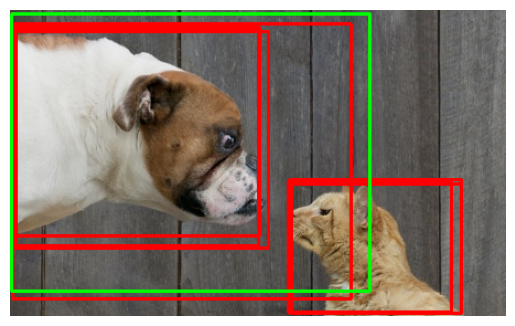

In [32]:
import cv2
import matplotlib.pyplot as plt

# Read the image
image = cv2.imread(img)

# Find the bbox with the highest score
max_score = -1
max_bbox = None


# Define colors
max_bbox_color = (0, 255, 0)  # Green for the highest score bbox
other_bbox_color = (0, 0, 255)  # Red for other bboxes

num_bbox = 0

# Plot all bboxes
for score, bbox in rest:
    num_bbox+=1
    #if num_bbox < 5:
    print(bbox)
    color = other_bbox_color
    cv2.rectangle(image, (int(bbox[0]), int(bbox[1])) ,(int(bbox[2]), int(bbox[3])), color, 2)
    

color = max_bbox_color
cv2.rectangle(image, (int(bboxe[0]), int(bboxe[1])) ,(int(bboxe[2]), int(bboxe[3])), color, 2)

# Convert the image from BGR to RGB for displaying with matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(image_rgb)
plt.axis('off')
plt.show()

In [33]:
fino qua

SyntaxError: invalid syntax (1318290342.py, line 1)

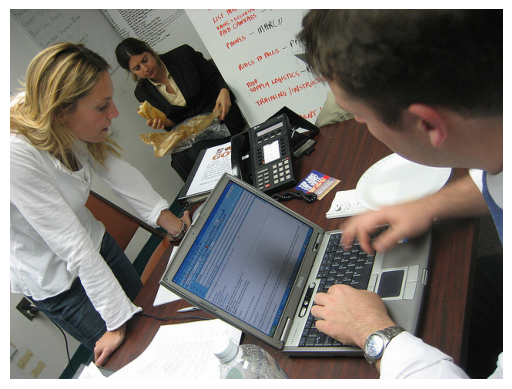

In [34]:
import cv2
import matplotlib.pyplot as plt

# Read the image
image = cv2.imread(zero_results[0]['file_name'])

bbox_gt = zero_results[0]['gt_bbox']
x, y, z, c = bbox_gt
y1=y 
x1=x 
y2=(y + c)
x2=(x + z)
# Define colors
max_bbox_color = (0, 255, 0)  # Green for the highest score bbox
other_bbox_color = (0, 0, 255)  # Red for other bboxes

# Plot all bboxes
for bbox in zero_results[0]['pred_bbox']:
    bbox = bbox.tensor[0]

    color = other_bbox_color
    cv2.rectangle(image, (int(bbox[0]), int(bbox[1])) ,(int(bbox[2]), int(bbox[3])), color, 2)
    

color = max_bbox_color
cv2.rectangle(image, (int(x1), int(y1)) ,(int(x2), int(y2)), color, 2)

# Convert the image from BGR to RGB for displaying with matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(image_rgb)
plt.axis('off')
plt.show()


# TRAINING Process

Definizione funzione per il calcolo della validation loss

In [35]:
from detectron2.engine import HookBase
from detectron2.data import build_detection_train_loader
import detectron2.utils.comm as comm
import torch


class ValidationLoss(HookBase):
    """
    A hook that computes validation loss during training.

    Attributes:
        cfg (CfgNode): The detectron2 config node.
        _loader (iterator): An iterator over the validation dataset.
    """

    def __init__(self, cfg):
        """
        Args:
            cfg (CfgNode): The detectron2 config node.
        """
        super().__init__()
        self.cfg = cfg.clone()
        # Switch to the validation dataset
        self.cfg.DATASETS.TRAIN = cfg.DATASETS.VAL
        # Build the validation data loader iterator
        self._loader = iter(build_detection_train_loader(self.cfg))

    def after_step(self):
        """
        Computes the validation loss after each training step.
        """
        # Get the next batch of data from the validation data loader
        data = next(self._loader)
        with torch.no_grad():
            # Compute the validation loss on the current batch of data
            loss_dict = self.trainer.model(data)

            # Check for invalid losses
            losses = sum(loss_dict.values())
            assert torch.isfinite(losses).all(), loss_dict

            # Reduce the loss across all workers
            loss_dict_reduced = {"val_" + k: v.item() for k, v in
                                 comm.reduce_dict(loss_dict).items()}
            losses_reduced = sum(loss for loss in loss_dict_reduced.values())

            # Save the validation loss in the trainer storage
            if comm.is_main_process():
                self.trainer.storage.put_scalars(total_val_loss=losses_reduced,
                                                 **loss_dict_reduced)

Creazione del Trainer

In [36]:
# Create the trainer object
trainer = DefaultTrainer(cfg)

# Create a custom validation loss object
val_loss = ValidationLoss(cfg)

# Register the custom validation loss object as a hook to the trainer
trainer.register_hooks([val_loss])

# Swap the positions of the evaluation and checkpointing hooks so that the validation loss is logged correctly
trainer._hooks = trainer._hooks[:-2] + trainer._hooks[-2:][::-1]

# Resume training from a checkpoint or load the initial model weights
trainer.resume_or_load(resume=False)

# Train the model
trainer.train()

[07/21 15:49:26 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): ResNet(
    (stem): BasicStem(
      (conv1): Conv2d(
        3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
        (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
      )
    )
    (res2): Sequential(
      (0): BottleneckBlock(
        (shortcut): Conv2d(
          64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): FrozenBatchNorm2d(num_features=256, eps=1e-05)
        )
        (conv1): Conv2d(
          64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
        (conv2): Conv2d(
          64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
        (conv3): Conv2d(
          64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): FrozenBatchNorm2d(num_features=256, eps=1e-05)
 

Plotting function

In [41]:
import ast
import json

import matplotlib.pyplot as plt
import numpy as np


def moving_average(a, n=3):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n


metrics_file = './detectron_output/metrics.json'

with open(metrics_file, 'r') as f:
    metrics = [ast.literal_eval(l[:-1]) for l in f.readlines()]
    print(metrics)
    f.close()

train_loss = [float(v['loss_box_reg']) for v in metrics if 'loss_box_reg' in v.keys()]
val_loss = [float(v['val_loss_box_reg']) for v in metrics if 'val_loss_box_reg' in v.keys()]

print(train_loss)
print(val_loss)

# N = 40

# train_loss_avg = moving_average(train_loss, n=N)
# val_loss_avg = moving_average(val_loss, n=N)

# plt.plot(range(20 * N - 1, 20 * len(train_loss), 20), train_loss_avg, label='train loss')
# plt.plot(range(20 * N - 1, 20 * len(train_loss), 20), val_loss_avg, label='val loss')
# plt.legend()
# plt.grid()
# plt.show()

[{'data_time': 0.000631271000003153, 'eta_seconds': 569.8611600299955, 'fast_rcnn/cls_accuracy': 0.9453125, 'iteration': 19, 'loss_box_reg': 0.0, 'loss_cls': 0.1499146819114685, 'loss_rpn_cls': 0.1809437945485115, 'loss_rpn_loc': 0.0, 'lr': 2.3976250000000003e-05, 'rank_data_time': 0.000631271000003153, 'roi_head/num_bg_samples': 128.0, 'roi_head/num_fg_samples': 0.0, 'rpn/num_neg_anchors': 256.0, 'rpn/num_pos_anchors': 0.0, 'time': 3.165895333499975, 'total_loss': 0.3132944479584694, 'total_val_loss': 0.37840475142002106, 'val_loss_box_reg': 0.0, 'val_loss_cls': 0.1669224351644516, 'val_loss_rpn_cls': 0.18750831484794617, 'val_loss_rpn_loc': 0.0}, {'data_time': 0.0006632914999897821, 'eta_seconds': 536.6555767199998, 'fast_rcnn/cls_accuracy': 0.95703125, 'iteration': 39, 'loss_box_reg': 0.0, 'loss_cls': 0.17022312432527542, 'loss_rpn_cls': 0.18800842761993408, 'loss_rpn_loc': 0.0, 'lr': 4.895125e-05, 'rank_data_time': 0.0006632914999897821, 'roi_head/num_bg_samples': 128.0, 'roi_head/

# Prediction Process

In [43]:
# Load config from a config file
trained_cfg = get_cfg()
trained_cfg.merge_from_file(model_zoo.get_config_file('COCO-Detection/faster_rcnn_R_50_C4_3x.yaml'))
trained_cfg.MODEL.WEIGHTS = './detectron_output/model_final.pth'
trained_cfg.MODEL.DEVICE = 'cpu'

# Create predictor instance
trained_predictor = DefaultPredictor(trained_cfg)

[07/21 16:12:21 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./detectron_output/model_final.pth ...


Skip loading parameter 'proposal_generator.rpn_head.conv.weight' to the model due to incompatible shapes: (2048, 2048, 3, 3) in the checkpoint but (1024, 1024, 3, 3) in the model! You might want to double check if this is expected.
Skip loading parameter 'proposal_generator.rpn_head.conv.bias' to the model due to incompatible shapes: (2048,) in the checkpoint but (1024,) in the model! You might want to double check if this is expected.
Skip loading parameter 'proposal_generator.rpn_head.objectness_logits.weight' to the model due to incompatible shapes: (15, 2048, 1, 1) in the checkpoint but (15, 1024, 1, 1) in the model! You might want to double check if this is expected.
Skip loading parameter 'proposal_generator.rpn_head.anchor_deltas.weight' to the model due to incompatible shapes: (60, 2048, 1, 1) in the checkpoint but (60, 1024, 1, 1) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due

In [44]:
trained_results = []

for i in test_dataset:
    file_name = i['file_name']
    im = cv2.imread(file_name)
    
    #print(i['annotations']['bbox'])
    gt_bbox = i['annotations']['bbox']
    gt_category_id = i['annotations']['category_id']

    outputs = trained_predictor(im)
    
    #print(outputs["instances"])
    # print(outputs["instances"].pred_boxes)
    # print("\n")
    # print(outputs["instances"].pred_boxes[2])
    # print('\npredicted classes\n')
    # print(outputs["instances"].pred_classes)
    # print('\ngt classes\n')
    # print(i['annotations']['category_id'])

    #pred_bbox = outputs["instances"].pred_boxes

    pred_bbox = exctract_bbox(outputs, gt_category_id, num_bbox=3)

    trained_results.append({"file_name": file_name ,"gt_bbox": gt_bbox, "pred_bbox": pred_bbox})
    break

TypeError: list indices must be integers or slices, not str

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Read the image
image = cv2.imread(trained_results[0]['file_name'])

bbox_gt = trained_results[0]['gt_bbox']
x, y, z, c = bbox_gt
y1=y 
x1=x 
y2=(y + c)
x2=(x + z)
# Define colors
max_bbox_color = (0, 255, 0)  # Green for the highest score bbox
other_bbox_color = (0, 0, 255)  # Red for other bboxes

# Plot all bboxes
for bbox in trained_results[0]['pred_bbox']:
    bbox = bbox.tensor[0]

    color = other_bbox_color
    cv2.rectangle(image, (int(bbox[0]), int(bbox[1])) ,(int(bbox[2]), int(bbox[3])), color, 2)
    

color = max_bbox_color
cv2.rectangle(image, (int(x1), int(y1)) ,(int(x2), int(y2)), color, 2)

# Convert the image from BGR to RGB for displaying with matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(image_rgb)
plt.axis('off')
plt.show()